# M2 — conditional low-rank Gaussian copula

This self-contained notebook explains how frozen per-entity forecast information predicts an origin-specific correlation matrix. See [Chapter 4](../../docs/scientific/04_dependence_models.md) and [Chapter 5](../../docs/scientific/05_training_sampling_scoring.md).

## Notation and scientific sample

$i$ indexes origin $t^{(i)}$, $g$ indexes $\mathcal E_g=\{k_1,\ldots,k_{K_g}\}$, and $\tau$ is one-based lead. $Y_{k,\tau}^{(i)}$ is random, $y_{k,\tau}^{(i)}$ is observed, $F_{k,\tau}^{(i)}$ is fixed, and $A_{g,\tau}^{(i)}=\sum_kY_{k,\tau}^{(i)}$. Define $V_{k,\tau}^{(i)}\in\{0,1\}$ and $V_{g,\tau}^{(i)}=\prod_{k\in\mathcal E_g}V_{k,\tau}^{(i)}$. When this product is one, $X_{g,\tau}^{(i)}=[v_{k,\tau}^{(i)}]_k\in\mathbb R^{K_g\times F}$ contains origin-measurable features and $\mathbf z_{g,\tau}^{(i)}\in\mathbb R^{K_g}$ contains Gaussianized pseudo-PIT scores. $X$ is a feature matrix; $V$ is validity.

The fixed marginal law concerns $Y_{k,\tau}^{(i)}$; M2 predicts only $R_{g,\tau}^{(i)}$, the copula correlation joining those marginals.

## Low-rank covariance construction

A shared entity-wise network returns $(\lambda_k,b_k)=f_\theta(v_k)$, with $\lambda_k\in\mathbb R^r$ and $\sigma_k=\mathrm{softplus}(b_k)+\sigma_{\min}>0$. Stacking rows gives $\Lambda\in\mathbb R^{K_g\times r}$ and
$$\Sigma=\Lambda\Lambda^\mathsf T+\mathrm{diag}(\sigma_1^2,\ldots,\sigma_{K_g}^2),\qquad R_{ab}=\Sigma_{ab}/\sqrt{\Sigma_{aa}\Sigma_{bb}}.$$
Aligned loading vectors imply positive shared covariance; opposing vectors imply negative covariance. The uniqueness term keeps full rank. Individual factor coordinates are rotation non-identifiable, so scientific interpretation belongs to $R$, not one column of $\Lambda$.

In [5]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'pyproject.toml').is_file()
)
CACHE_ROOT = PROJECT_ROOT / 'artifacts' / 'cache'
SOURCE_ROOT = str(PROJECT_ROOT / 'src')
if SOURCE_ROOT not in sys.path:
    sys.path.insert(0, SOURCE_ROOT)

from simcast.config import load_base_config, load_method_config, resolve_run_config
from simcast.experiments import locate_compatible_cache
from simcast.fm.cache import load_pit_library
from simcast.fm.pit import dependence_pit_scores
from simcast.sampling.gaussian_copula import generate_scenarios, sample_gaussian_uniforms
from simcast.training.checkpoint import load_conditional_checkpoint
from simcast.cli.train_dependence import train_from_config
from simcast.cli.evaluate import evaluate_from_config

BASE_FILE = 'configs/bases/liander2024/solar_park.yaml'
METHOD_FILE = 'configs/methods/m2_conditional_low_rank.yaml'
BASE_OVERRIDES = (f'output.cache_dir={CACHE_ROOT}',)
METHOD_OVERRIDES = ()
FIT_IF_MISSING = True
RUN_EVALUATION = True
VISUALIZE_FITTED_MODEL = True
RUN_DIR = PROJECT_ROOT / 'runs' / 'notebook_walkthrough' / 'm2_conditional_low_rank'

base = load_base_config(PROJECT_ROOT / BASE_FILE, overrides=BASE_OVERRIDES)
method = load_method_config(PROJECT_ROOT / METHOD_FILE, overrides=METHOD_OVERRIDES)
config = resolve_run_config(base, method)
cache_dir = locate_compatible_cache(base)
library = load_pit_library(cache_dir, access='training')
ds = library.dataset
entity_ids = [str(value) for value in ds.entity_id.values]
K_g = len(entity_ids)
print({'g': base.data.entity_type, 'K_g': K_g, 'rank r': method.model.latent_rank})


{'g': 'solar_park', 'K_g': 5, 'rank r': 4}


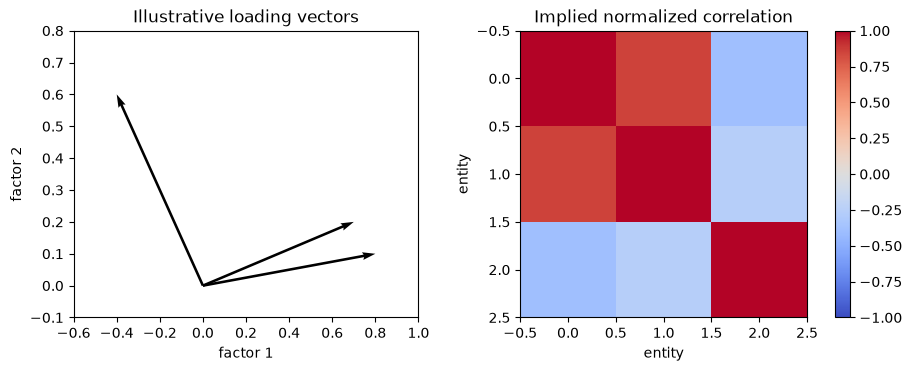

In [6]:
Lambda = np.array([[0.8, 0.1], [0.7, 0.2], [-0.4, 0.6]])
sigma = np.array([0.3, 0.3, 0.3])
Sigma = Lambda @ Lambda.T + np.diag(sigma**2)
R = Sigma / np.sqrt(np.outer(np.diag(Sigma), np.diag(Sigma)))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), constrained_layout=True)
axes[0].quiver(
    np.zeros(3), np.zeros(3), Lambda[:, 0], Lambda[:, 1],
    angles='xy', scale_units='xy', scale=1,
)
axes[0].set(
    xlim=(-0.6, 1), ylim=(-0.1, 0.8),
    xlabel='factor 1', ylabel='factor 2', title='Illustrative loading vectors',
)
image = axes[1].imshow(R, vmin=-1, vmax=1, cmap='coolwarm')
axes[1].set(
    title='Implied normalized correlation', xlabel='entity', ylabel='entity',
)
fig.colorbar(image, ax=axes[1])
plt.show()


## Estimation

For one complete score vector, M2 minimizes $\mathcal L=\tfrac12[\log|R|+\mathbf z^\mathsf T(R^{-1}-I)\mathbf z]$. Training uses chronological training cases; checkpoint selection uses chronological validation pseudo-NLL. The word “pseudo” records that $z$ arose from finite quantile cells. M2's shared network processes each $v_k$ separately before the low-rank interaction, so it is permutation equivariant but not set-contextual before producing loadings.

In [7]:
if FIT_IF_MISSING and not (RUN_DIR/'best.pt').is_file():
    train_from_config(config, cache_dir=cache_dir, output_dir=RUN_DIR)
if RUN_EVALUATION:
    evaluate_from_config(
        config,
        methods=('conditional_low_rank',),
        method_runs={'conditional_low_rank': RUN_DIR},
        cache_dir=cache_dir,
        output_dir=RUN_DIR / 'evaluation',
    )


FileExistsError: [Errno 17] File exists: '/home/kbolat/Python/simcast/runs/notebook_walkthrough/m2_conditional_low_rank/evaluation'

## Conditional correlation across information states

A fitted M2 checkpoint maps every information state $X_{g,\tau}^{(i)}$ to a correlation matrix $R_{g,\tau}^{(i)}$. The figure compares two complete cached cases. Its third panel is the signed difference $R_{g,\tau_b}^{(i_b)}-R_{g,\tau_a}^{(i_a)}$, so a positive cell means that M2 predicts stronger correlation in the second state. This is a direct visualization of conditional dependence, not a comparison of predictive scores.

The computation requires `RUN_DIR/best.pt`. If it is absent, point `RUN_DIR` to a compatible fitted M2 run or explicitly enable `FIT_IF_MISSING`. An untrained network is never presented as a scientific result.

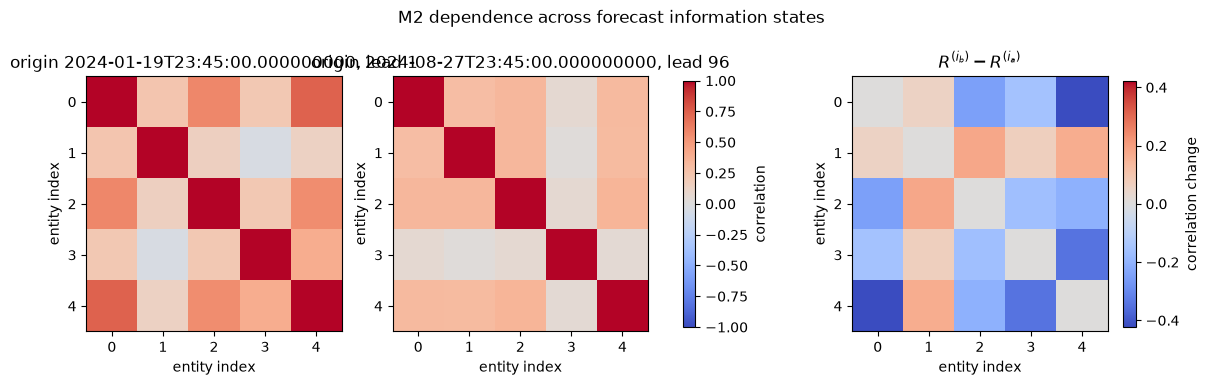

In [8]:
checkpoint_path = RUN_DIR / 'best.pt'
m2_visuals_ready = VISUALIZE_FITTED_MODEL and checkpoint_path.is_file()

if m2_visuals_ready:
    checkpoint = load_conditional_checkpoint(checkpoint_path)
    if checkpoint.method != 'conditional_low_rank':
        raise ValueError('The selected checkpoint is not an M2 model.')
    if checkpoint.entity_ids != tuple(entity_ids):
        raise ValueError('The checkpoint entity order does not match the cache.')

    training = np.asarray(ds['split'].values) == 'train'
    valid = training[:, None] & np.asarray(ds['pit_valid'].values, dtype=bool)
    candidates = np.argwhere(valid)
    if len(candidates) == 0:
        raise ValueError('No complete training case is available for visualization.')

    positions = np.linspace(0, len(candidates) - 1, min(2, len(candidates)), dtype=int)
    selected = candidates[np.unique(positions)]
    levels = torch.tensor(np.asarray(ds['quantile'].values).copy(), dtype=torch.float32)
    locations = None
    if 'latitude' in ds and 'longitude' in ds:
        coordinates = np.stack((ds['latitude'].values, ds['longitude'].values), axis=-1)
        locations = torch.tensor(coordinates.copy(), dtype=torch.float32)

    matrices = []
    case_features = []
    with torch.no_grad():
        for origin_index, lead_index in selected:
            embeddings = torch.tensor(
                np.asarray(ds['forecast_embedding'].values[origin_index:origin_index + 1]).copy(),
                dtype=torch.float32,
            )
            predictions = torch.tensor(
                np.asarray(ds['quantile_prediction'].values[origin_index:origin_index + 1]).copy(),
                dtype=torch.float32,
            )
            features = checkpoint.feature_builder.transform(
                embeddings, predictions, levels, locations
            )[0, :, lead_index]
            case_features.append(features)
            matrices.append(checkpoint.model(features).numpy())

    if len(matrices) == 1:
        matrices.append(matrices[0].copy())
        selected = np.vstack((selected, selected))

    difference = matrices[1] - matrices[0]
    difference_limit = max(float(np.abs(difference).max()), 1e-6)
    labels = [
        f'origin {ds.origin_timestamp.values[i]}, lead {int(ds.lead.values[tau])}'
        for i, tau in selected
    ]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, matrix, label in zip(axes[:2], matrices, labels):
        image = ax.imshow(matrix, vmin=-1, vmax=1, cmap='coolwarm')
        ax.set(title=label, xlabel='entity index', ylabel='entity index')

    difference_image = axes[2].imshow(
        difference, vmin=-difference_limit, vmax=difference_limit, cmap='coolwarm'
    )
    axes[2].set(
        title=r'$R^{(i_b)}-R^{(i_a)}$',
        xlabel='entity index',
        ylabel='entity index',
    )
    fig.colorbar(image, ax=axes[:2], label='correlation', shrink=0.8)
    fig.colorbar(difference_image, ax=axes[2], label='correlation change', shrink=0.8)
    fig.suptitle('M2 dependence across forecast information states')
    plt.show()
else:
    print(f'No fitted M2 checkpoint at {checkpoint_path}.')


## Factor decomposition of one conditional matrix

For the first selected information state, M2 predicts a loading vector $\lambda_k\in\mathbb R^r$ and uniqueness scale $\sigma_k>0$ for every entity. The left panel displays the rows of $\Lambda=[\lambda_k^\mathsf T]_k$; the right panel displays $\sigma_k$. Together they generate $\Sigma=\Lambda\Lambda^\mathsf T+\mathrm{diag}(\sigma_1^2,\ldots,\sigma_{K_g}^2)$ before normalization to $R$. Factor columns are rotation-dependent, so individual columns should not be assigned a unique physical meaning.

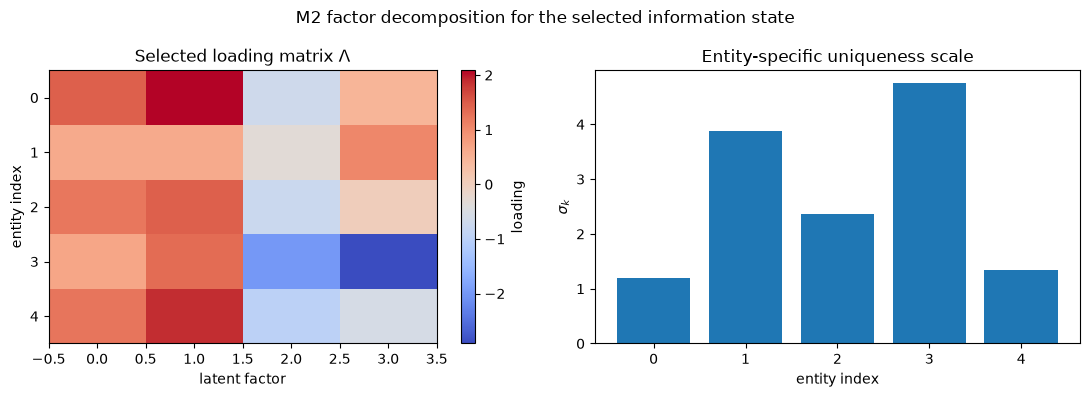

In [9]:
if m2_visuals_ready:
    with torch.no_grad():
        loadings, sigma = checkpoint.model.factor_parameters(case_features[0])

    fig, (ax_loadings, ax_sigma) = plt.subplots(1, 2, figsize=(11, 4))
    image = ax_loadings.imshow(loadings.numpy(), aspect='auto', cmap='coolwarm')
    ax_loadings.set(
        xlabel='latent factor',
        ylabel='entity index',
        title=r'Selected loading matrix $\Lambda$',
    )
    fig.colorbar(image, ax=ax_loadings, label='loading')

    ax_sigma.bar(np.arange(K_g), sigma.numpy())
    ax_sigma.set(
        xlabel='entity index',
        ylabel=r'$\sigma_k$',
        title='Entity-specific uniqueness scale',
    )
    fig.suptitle('M2 factor decomposition for the selected information state')
    plt.tight_layout()
    plt.show()
else:
    print('A fitted M2 checkpoint is required for the factor decomposition.')


## Historical scores and one conditional Gaussian law

The left panel shows complete historical training scores at the selected lead, pooled across forecast origins. The right panel shows draws from $\mathcal N(\mathbf0,R_{g,\tau}^{(i)})$ for the first selected information state. The displayed entity pair has the largest absolute off-diagonal correlation in that conditional matrix. Because the historical panel mixes many information states while the M2 panel conditions on one state, the figure explains the fitted dependence mechanism; it is not an out-of-sample calibration assessment.

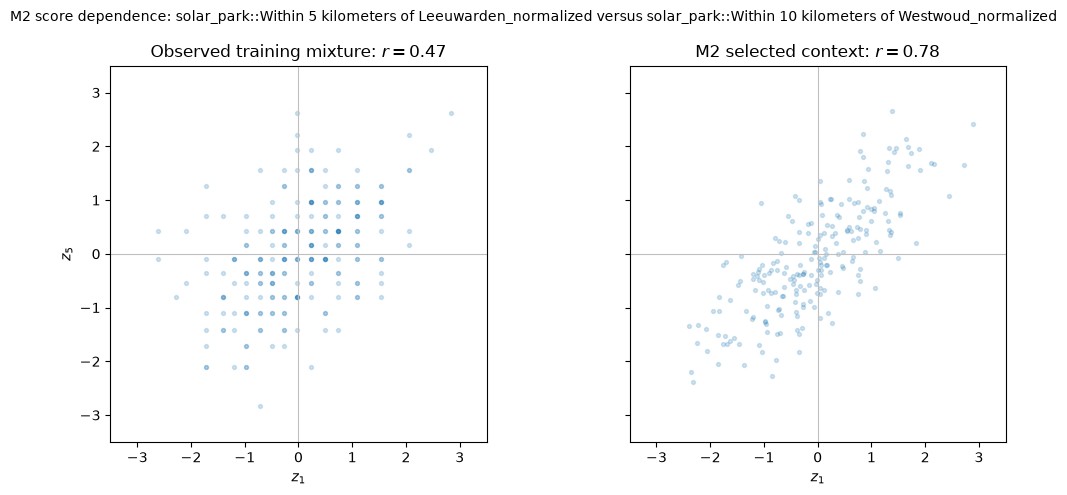

In [10]:
if m2_visuals_ready:
    origin_index, lead_index = map(int, selected[0])
    R_fitted = matrices[0]

    strength = np.abs(R_fitted.copy())
    np.fill_diagonal(strength, -np.inf)
    entity_a, entity_b = np.unravel_index(np.argmax(strength), strength.shape)

    scores, _ = dependence_pit_scores(
        torch.tensor(np.asarray(ds["pit_u"].values).copy()),
        torch.tensor(np.asarray(ds["pit_z"].values).copy()),
        torch.tensor(training.copy()),
        levels,
        mode=config.pit.dependence_transform,
        eps=config.pit.eps,
    )
    observed = scores.numpy()[training, :, lead_index]
    observed = observed[np.isfinite(observed).all(axis=1)]

    generator = torch.Generator().manual_seed(config.sampling.evaluation_seed)
    fitted_u = sample_gaussian_uniforms(
        torch.tensor(R_fitted, dtype=torch.float32),
        len(observed),
        generator=generator,
    )
    fitted_z = torch.special.ndtri(fitted_u).numpy()

    step = max(1, len(observed) // 5000)
    observed_pair = observed[::step][:, [entity_a, entity_b]]
    fitted_pair = fitted_z[::step][:, [entity_a, entity_b]]
    limit = max(
        3.5,
        np.nanpercentile(np.abs(np.vstack((observed_pair, fitted_pair))), 99.5),
    )

    observed_r = np.corrcoef(observed, rowvar=False)[entity_a, entity_b]
    fitted_r = np.corrcoef(fitted_z, rowvar=False)[entity_a, entity_b]
    panels = (
        (observed_pair, fr"Observed training mixture: $r={observed_r:.2f}$"),
        (fitted_pair, fr"M2 selected context: $r={fitted_r:.2f}$"),
    )

    fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
    for ax, (points, title) in zip(axes, panels):
        ax.scatter(points[:, 0], points[:, 1], s=8, alpha=0.2)
        ax.axhline(0, color="0.75", lw=0.8)
        ax.axvline(0, color="0.75", lw=0.8)
        ax.set(
            xlim=(-limit, limit), ylim=(-limit, limit), aspect="equal",
            xlabel=fr"$z_{{{entity_a + 1}}}$", title=title,
        )

    axes[0].set_ylabel(fr"$z_{{{entity_b + 1}}}$")
    fig.suptitle(
        f"M2 score dependence: {entity_ids[entity_a]} "
        f"versus {entity_ids[entity_b]}",
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()
else:
    print("A fitted M2 checkpoint is required for the score-space comparison.")

## From conditional ranks to entity and aggregate scenarios

For the same selected case, M2 draws $X^{(m)}\sim\mathcal N(\mathbf0,R_{g,\tau}^{(i)})$ and transforms each component to a rank $U_k^{(m)}=\Phi(X_k^{(m)})$. The fixed inverse marginal forecast then gives $\widetilde Y_{k,\tau}^{(i,m)}=(\widehat F_{k,\tau}^{(i)})^{-1}(U_k^{(m)})$, and summation gives $\widetilde A_{g,\tau}^{(i,m)}=\sum_{k\in\mathcal E_g}\widetilde Y_{k,\tau}^{(i,m)}$. The panels follow the same Monte Carlo draws through probability space, physical entity space, and aggregate space.

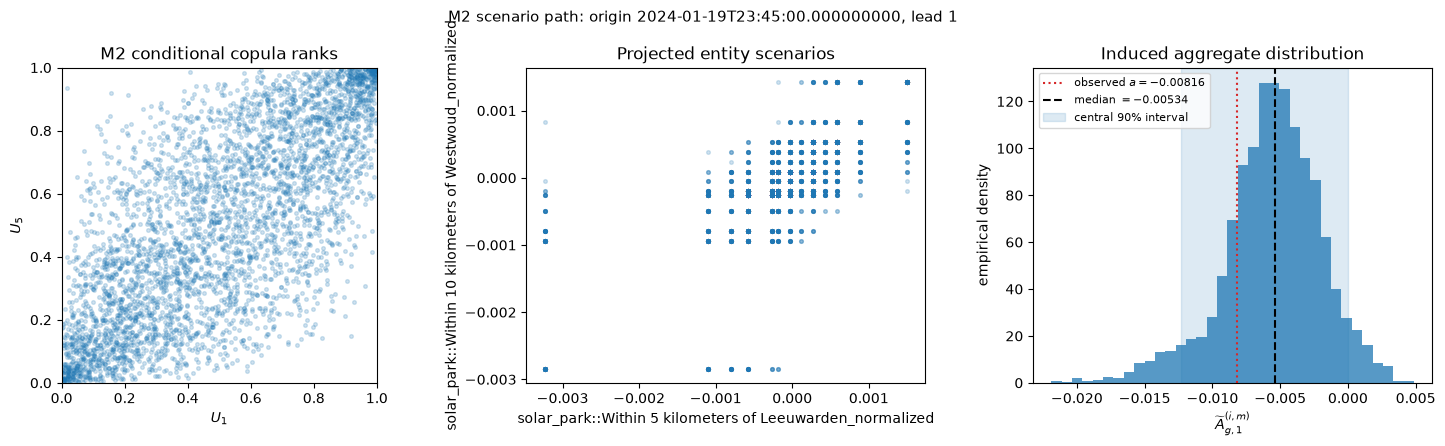

In [11]:
if m2_visuals_ready:
    qhat = torch.tensor(
        np.asarray(ds["quantile_prediction"].values[origin_index, :, lead_index]).copy(),
        dtype=torch.float32,
    )
    generator = torch.Generator().manual_seed(config.sampling.evaluation_seed)
    scenarios = generate_scenarios(
        torch.tensor(R_fitted, dtype=torch.float32), qhat, levels,
        num_samples=config.sampling.num_samples,
        generator=generator,
        marginal_mode=config.pit.mode,
    )

    u = scenarios.uniforms.numpy()
    y = scenarios.entity_samples.numpy()
    aggregate = scenarios.aggregate_samples.numpy()
    observed = float(ds["true_y"].values[origin_index, :, lead_index].sum())
    q05, median, q95 = np.quantile(aggregate, [0.05, 0.5, 0.95])
    lead = int(ds["lead"].values[lead_index])
    origin = ds["origin_timestamp"].values[origin_index]

    fig, (ax_u, ax_y, ax_a) = plt.subplots(1, 3, figsize=(15, 4.5))

    ax_u.scatter(u[:, entity_a], u[:, entity_b], s=7, alpha=0.2)
    ax_u.set(
        xlim=(0, 1), ylim=(0, 1), aspect="equal",
        xlabel=fr"$U_{{{entity_a + 1}}}$",
        ylabel=fr"$U_{{{entity_b + 1}}}$",
        title="M2 conditional copula ranks",
    )

    ax_y.scatter(y[:, entity_a], y[:, entity_b], s=7, alpha=0.2)
    ax_y.set(
        xlabel=entity_ids[entity_a], ylabel=entity_ids[entity_b],
        title="Projected entity scenarios",
    )

    ax_a.hist(aggregate, bins=35, density=True, alpha=0.75)
    ax_a.axvline(observed, color="C3", ls=":", label=fr"observed $a={observed:.3g}$")
    ax_a.axvline(median, color="black", ls="--", label=fr"median $={median:.3g}$")
    ax_a.axvspan(q05, q95, color="C0", alpha=0.15, label="central 90% interval")
    ax_a.set(
        xlabel=fr"$\widetilde A_{{g,{lead}}}^{{(i,m)}}$",
        ylabel="empirical density", title="Induced aggregate distribution",
    )
    ax_a.legend(fontsize=8)

    fig.suptitle(f"M2 scenario path: origin {origin}, lead {lead}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("A fitted M2 checkpoint is required for scenario propagation.")

## Controls and interpretation

`method.features.*` determines $v_k$. `method.model.latent_rank`, `hidden_dims`, `dropout`, `sigma_floor`, and `jitter` determine the map and covariance. `method.optimization.*` controls estimation. `ConditionalLowRankGaussianCopula` implements the matrix; `gaussian_copula_pseudo_nll` implements the objective. A gain over M1 supports predictable context variation under this parameterization; failure to gain is equally informative and does not imply absence of dependence.